Sistema de Análise de Crédito  
Nomes: Kauã de Oliveira Ribeiro, João Gabriel F. Ribeiro

In [9]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
!pip install category_encoders
from category_encoders import TargetEncoder
from scipy.stats import mstats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Análise Geral dos Datasets

O projeto utiliza dois datasets principais:

1. **`application_record.csv`**  
   Contém informações cadastrais dos clientes, como gênero, renda anual, escolaridade, estado civil, tipo de moradia, idade, tempo empregado, profissão, quantidade de filhos e número de membros da família.

2. **`credit_record.csv`**  
   Contém o histórico mensal de crédito dos clientes, indicando o comportamento de pagamento ao longo do tempo por meio da coluna `STATUS`.

A coluna **`ID`** é a chave de ligação entre os dois datasets. É a partir dela que podemos combinar as informações cadastrais dos clientes com o histórico de comportamento financeiro.

---

# Observações sobre o `application_record.csv`

O dataset **`application_record.csv`** possui uma grande quantidade de registros cadastrais. Cada linha representa um cliente ou uma solicitação associada a um cliente.

Algumas variáveis são numéricas, como:

- **`CNT_CHILDREN`**: quantidade de filhos;
- **`AMT_INCOME_TOTAL`**: renda anual;
- **`DAYS_BIRTH`**: quantidade de dias desde o nascimento;
- **`DAYS_EMPLOYED`**: quantidade de dias de emprego;
- **`CNT_FAM_MEMBERS`**: quantidade de familiares.

Outras variáveis são categóricas, como:

- **`CODE_GENDER`**: gênero;
- **`FLAG_OWN_CAR`**: posse de carro;
- **`FLAG_OWN_REALTY`**: posse de imóvel;
- **`NAME_INCOME_TYPE`**: tipo de renda;
- **`NAME_EDUCATION_TYPE`**: escolaridade;
- **`NAME_FAMILY_STATUS`**: estado civil;
- **`NAME_HOUSING_TYPE`**: tipo de moradia;
- **`OCCUPATION_TYPE`**: profissão.

Para a coluna **`OCCUPATION_TYPE`**, que possui muitos valores ausentes, ao invés de remove-los, achamos mais adequado preencher os valores nulos com uma nova categoria cujo valor é **`Nao_Informado`**, evitando perda de dados.

Também é importante verificar possíveis outliers, principalmente em:

- **`AMT_INCOME_TOTAL`**, Rendas muito altas;
- **`CNT_CHILDREN`**, Quantidade de filhos muito acima do comum;
- **`CNT_FAM_MEMBERS`**, Famílias muito grandes.

Além disso, a coluna **`DAYS_EMPLOYED`** apresenta valores positivos, o que não deveria acontecer. Estes valores estão associados a clientes sem vínculo empregatício ativo, como pensionistas.

---

# Observações sobre o `credit_record.csv`

O dataset **`credit_record.csv`** contém o histórico mensal de crédito dos clientes. Cada linha representa o status de pagamento de um cliente em determinado mês.

A coluna **`MONTHS_BALANCE`** indica o mês analisado:

- **0** representa o mês mais recente;
- valores negativos representam meses anteriores.

A coluna **`STATUS`** representa o comportamento de pagamento:

- **C**: crédito quitado/pago;
- **X**: sem empréstimo no mês;
- **0**: pagamento regular ou atraso muito pequeno;
- **1**: atraso leve;
- **2, 3, 4 e 5**: atrasos mais graves.

A maior parte dos registros está concentrada nos status **C**, **0** e **X**, indicando comportamento regular, crédito quitado ou ausência de crédito ativo no mês.

Por outro lado, os atrasos, representados pelos status **1, 2, 3, 4 e 5**, aparecem em uma parcela muito pequena da base, o que é normal para essa aplicação do sistema financeiro nos quais essas análises foram feitas.

Esse comportamento, mesmo positivo, atrapalha a análise do dataset por ser fortemente desbalanceado, já que existem muito mais registros de bons comportamentos do que de atrasos.

# **Etapa 1: Base de Dados**

In [10]:
# Importa os arquivos csv com os dados dos clientes
app_df = pd.read_csv("/application_record.csv")

credit_df = pd.read_csv("/credit_record.csv")

# Forçando o Pandas a mostrar todas as colunas das tabelas
pd.set_option('display.max_columns', None)

# Exibe as bases de dados que serão utilizadas no projeto extraídas do link abaixo
# https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction
display(app_df)
print()
display(credit_df)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [11]:
# Renomeando as colunas da tabela de application_record
app_df.rename(columns={
    'CODE_GENDER': 'Genero',
    'FLAG_OWN_CAR': 'Tem_Carro',
    'FLAG_OWN_REALTY': 'Tem_Imovel',
    'CNT_CHILDREN': 'Qtd_Filhos',
    'AMT_INCOME_TOTAL': 'Renda_Anual',
    'NAME_INCOME_TYPE': 'Tipo_Renda',
    'NAME_EDUCATION_TYPE': 'Escolaridade',
    'NAME_FAMILY_STATUS': 'Estado_Civil',
    'NAME_HOUSING_TYPE': 'Tipo_Moradia',
    'DAYS_BIRTH': 'Idade',
    'DAYS_EMPLOYED': 'Anos_Empregado',
    'FLAG_MOBIL': 'Tem_Celular',
    'FLAG_WORK_PHONE': 'Tem_Tel_Trabalho',
    'FLAG_PHONE': 'Tem_Tel_Fixo',
    'FLAG_EMAIL': 'Tem_Email',
    'OCCUPATION_TYPE': 'Profissao',
    'CNT_FAM_MEMBERS': 'Tamanho_Familia'
}, inplace=True)

# Convertendo as colunas de idade e anos empregado de dias negativos para anos
app_df['Idade'] = np.abs(round(app_df['Idade'] / 365.25))
app_df['Anos_Empregado'] = np.where(
    app_df['Anos_Empregado'] > 0, 0,
    np.abs(round(app_df['Anos_Empregado'] / 365.25))
)

# Trocando os valores de 'Y' e 'N' por 'S' e 'N'
app_df['Tem_Carro']  = app_df['Tem_Carro'].map({'Y': 'S', 'N': 'N'})
app_df['Tem_Imovel'] = app_df['Tem_Imovel'].map({'Y': 'S', 'N': 'N'})

# Renomeando as colunas da tabela de credit_record
credit_df.rename(columns={
    'MONTHS_BALANCE': 'Meses_no_Banco',
    'STATUS': 'Status_Pagamento'
}, inplace=True)

status_map = {
    'C': 'Pago (Em dia)',
    'X': 'Sem empréstimo',
    '0': 'Atraso leve (1-29 dias)',
    '1': 'Atraso médio (30-59 dias)',
    '2': 'Atraso grave (60-89 dias)',
    '3': 'Atraso grave (90-119 dias)',
    '4': 'Atraso grave (120-149 dias)',
    '5': 'Dívida (>150 dias)'
}
credit_df['Status_Descricao'] = credit_df['Status_Pagamento'].map(status_map)

In [12]:
MESES_AVALIACAO = 12  # Janela de avaliação de risco -> Consideramos o número de meses ao lado como a janela avaliada pelo banco na ánalise de crédito

# Analisando a tabela credit_record com base no intervalo de análise definido anteriormente
historico_passado   = credit_df[credit_df['Meses_no_Banco'] < -MESES_AVALIACAO]
periodo_avaliacao   = credit_df[credit_df['Meses_no_Banco'] >= -MESES_AVALIACAO]

# Criando a coluna alvo que utilizaremos nos modelos criados (Mau Pagador = Atraso grave no período avaliado)
periodo_avaliacao = periodo_avaliacao.copy()
periodo_avaliacao['Mau_Pagador'] = periodo_avaliacao['Status_Pagamento'].isin(
    ['2', '3', '4', '5']
)
target_df = periodo_avaliacao.groupby('ID')['Mau_Pagador'].max().reset_index()

# Criando as colunas de features dos clientes com base nos históricos deles
historico_features = historico_passado.groupby('ID').agg(
    Qtd_Meses_Historico        = ('Status_Pagamento', 'count'),
    Qtd_Atrasos_Leves          = ('Status_Pagamento', lambda x: x.isin(['0', '1']).sum()),
    Qtd_Atrasos_Graves         = ('Status_Pagamento', lambda x: x.isin(['2', '3', '4', '5']).sum()),
    Qtd_Meses_Pagos            = ('Status_Pagamento', lambda x: (x == 'C').sum()),
    Qtd_Meses_Sem_Emprestimo   = ('Status_Pagamento', lambda x: (x == 'X').sum()),
).reset_index()

historico_features['Percentual_Atrasos_Graves'] = (
    historico_features['Qtd_Atrasos_Graves'] / historico_features['Qtd_Meses_Historico']
)

In [13]:
# Unindo as tabelas em um único dataframe para facilitar a utilização dos modelos criados
df = app_df.merge(target_df, on='ID', how='inner')
df = df.merge(historico_features, on='ID', how='left')

# Preenchendo os valores faltantes caso existam
df['Profissao'] = df['Profissao'].fillna('Nao Informado')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Convertendo a coluna alvo para inteiro
df['Mau_Pagador'] = df['Mau_Pagador'].astype(int)

# Duplica o dataframe para que este seja utilizado no modelo não supervisionado, sem passar pela winsorização
df_puro = df.copy()

# Winsorização do dataframe
# Trata os outliers extremos da base de dados (1% Mais ricos) antes do split
# Evita que esses valores mais absurdos distorçam o modelo
df['Renda_Anual'] = mstats.winsorize(df['Renda_Anual'], limits=[0, 0.01])

In [14]:
print("Base de dados organizada com sucesso!")
print(f"Taxa de maus pagadores: {df['Mau_Pagador'].mean():.2%}\n")
display(df)

Base de dados organizada com sucesso!
Taxa de maus pagadores: 0.87%



,ID,Genero,Tem_Carro,Tem_Imovel,Qtd_Filhos,Renda_Anual,Tipo_Renda,Escolaridade,Estado_Civil,Tipo_Moradia,Idade,Anos_Empregado,Tem_Celular,Tem_Tel_Trabalho,Tem_Tel_Fixo,Tem_Email,Profissao,Tamanho_Familia,Mau_Pagador,Qtd_Meses_Historico,Qtd_Atrasos_Leves,Qtd_Atrasos_Graves,Qtd_Meses_Pagos,Qtd_Meses_Sem_Emprestimo,Percentual_Atrasos_Graves
0,5008804,M,S,S,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,33.0,12.0,1,1,0,0,Nao Informado,2.0,0,3.0,2.0,0.0,0.0,1.0,0.000000
1,5008805,M,S,S,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,33.0,12.0,1,1,0,0,Nao Informado,2.0,0,2.0,1.0,0.0,0.0,1.0,0.000000
2,5008806,M,S,S,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,59.0,3.0,1,0,0,0,Security staff,2.0,0,17.0,4.0,0.0,0.0,13.0,0.000000
3,5008808,F,N,S,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.0,8.0,1,0,1,1,Sales staff,1.0,0,16.0,6.0,0.0,0.0,0.0,0.000000
4,5008810,F,N,S,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.0,8.0,1,0,1,1,Sales staff,1.0,0,14.0,6.0,0.0,2.0,6.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29746,5149828,M,S,S,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,47.0,7.0,1,0,0,0,Managers,2.0,1,16.0,6.0,0.0,0.0,0.0,0.000000
29747,5149834,F,N,S,0,157500.0,Commercial associate,Higher education,Married,House / apartment,34.0,4.0,1,0,1,1,Medicine staff,2.0,1,11.0,8.0,3.0,0.0,0.0,0.272727
29748,5149838,F,N,S,0,157500.0,Pensioner,Higher education,Married,House / apartment,34.0,4.0,1,0,1,1,Medicine staff,2.0,0,20.0,8.0,11.0,1.0,0.0,0.550000
29749,5150049,F,N,S,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,49.0,2.0,1,0,0,0,Sales staff,2.0,1,16.0,6.0,0.0,0.0,0.0,0.000000


# **Etapa 2: Análise Gráfica**

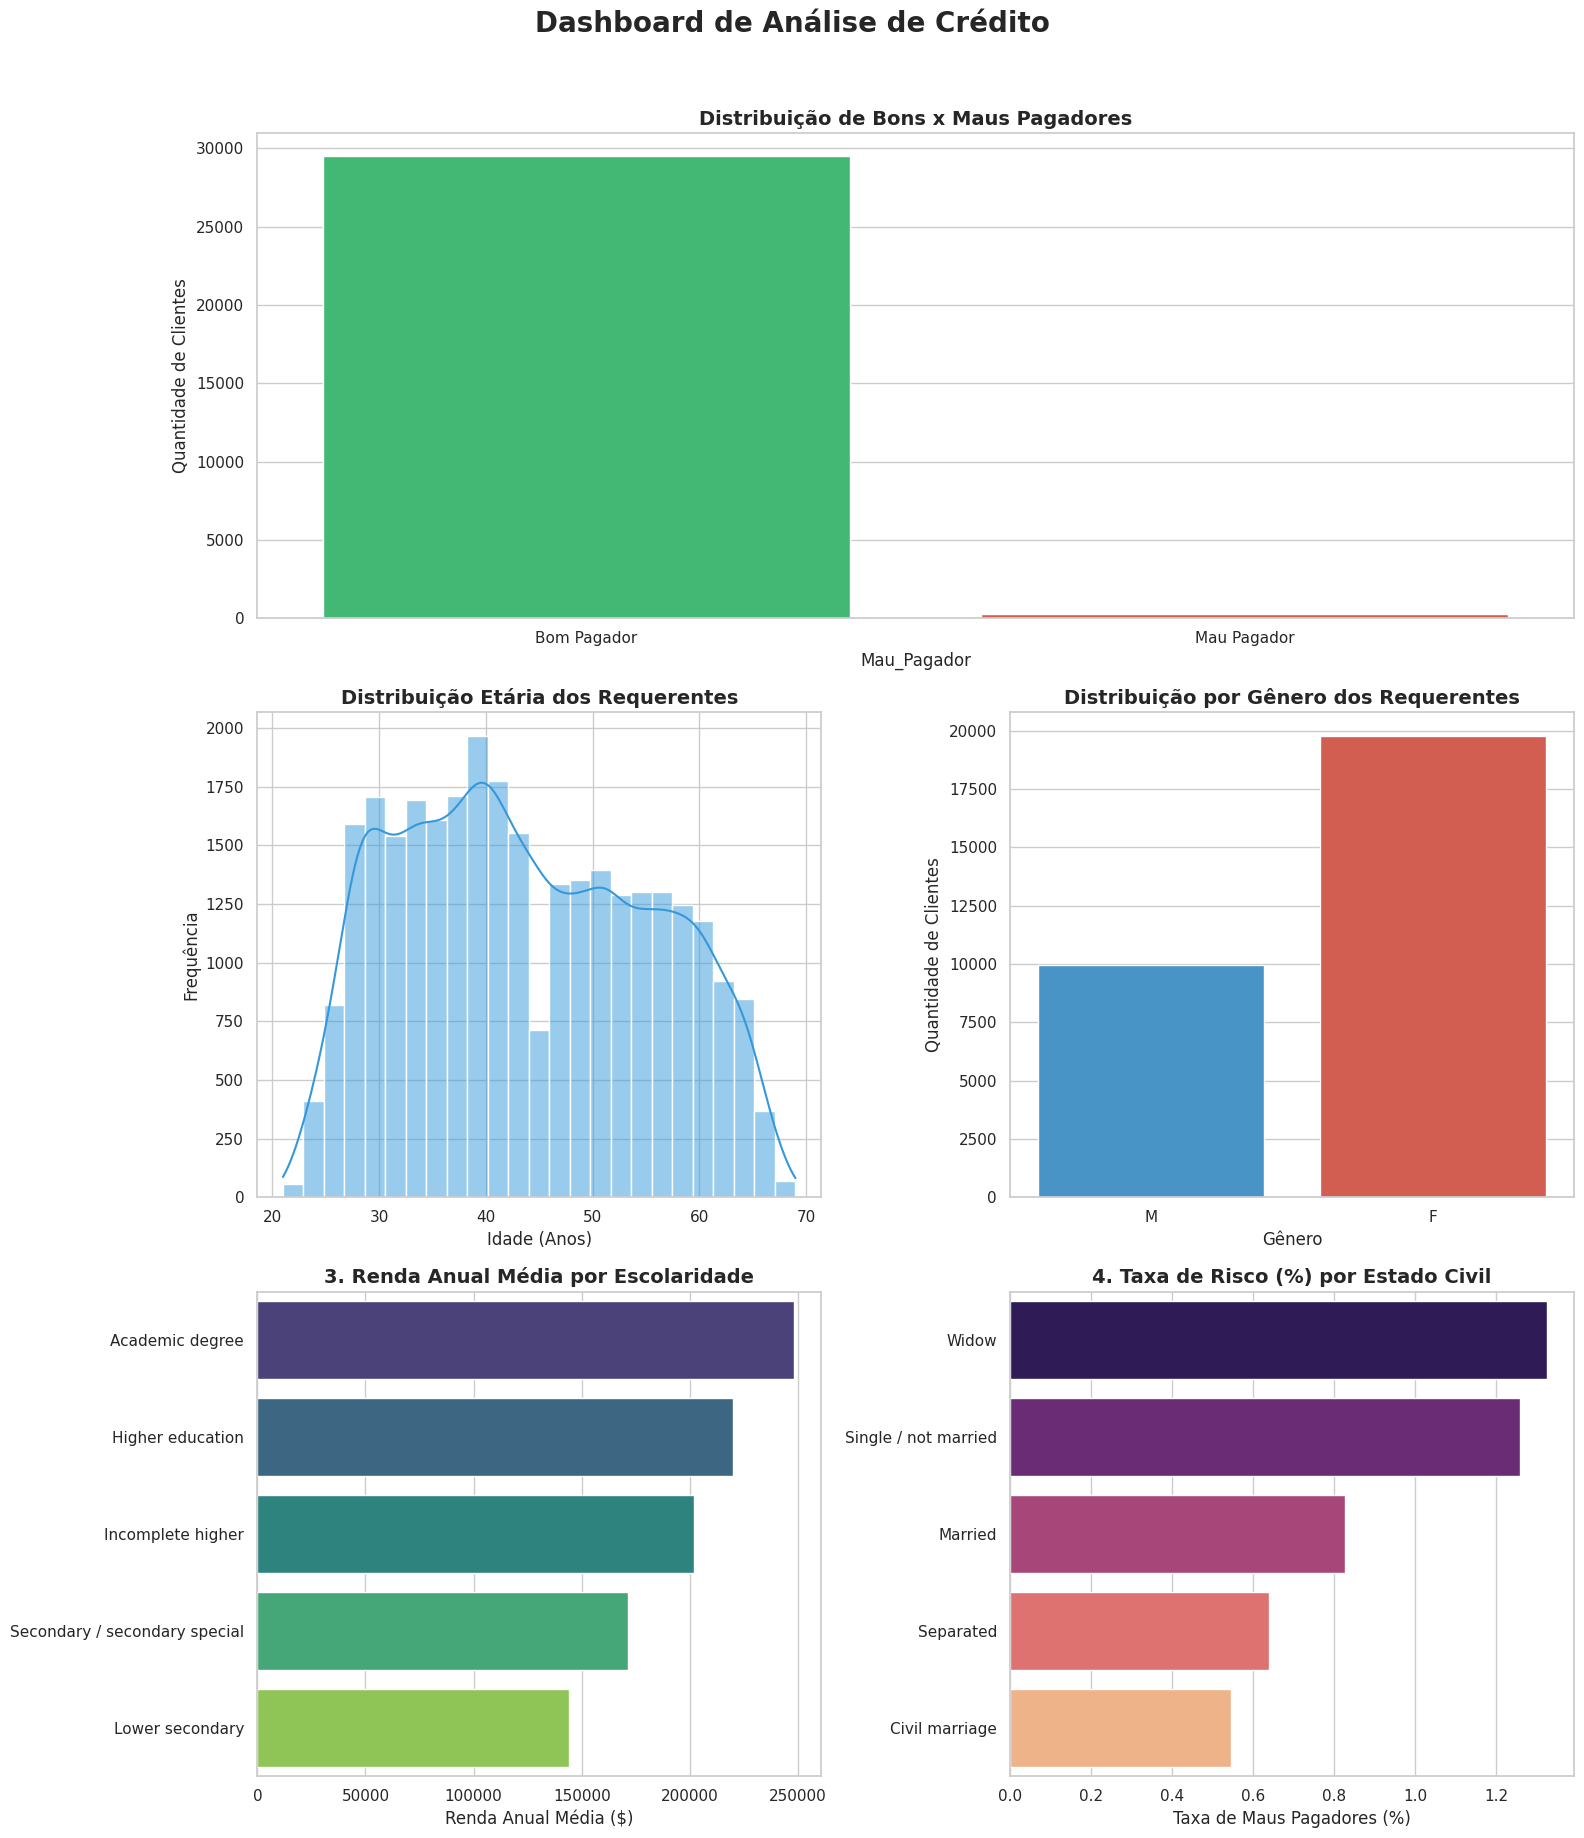

In [15]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 18)

fig = plt.figure()
fig.suptitle('Dashboard de Análise de Crédito', fontsize=20, fontweight='bold', y=1.02)

gs = fig.add_gridspec(3, 2)

ax0 = fig.add_subplot(gs[0, :])
sns.countplot(data=df, x='Mau_Pagador', hue='Mau_Pagador', palette=['#2ecc71', '#e74c3c'], ax=ax0, legend=False)
ax0.set_title('Distribuição de Bons x Maus Pagadores', fontweight='bold', fontsize=14)
ax0.set_xticks([0, 1])
ax0.set_xticklabels(['Bom Pagador', 'Mau Pagador'])
ax0.set_ylabel('Quantidade de Clientes')

ax1 = fig.add_subplot(gs[1, 0])
sns.histplot(data=df, x='Idade', kde=True, bins=25, color='#3498db', ax=ax1)
ax1.set_title('Distribuição Etária dos Requerentes', fontweight='bold', fontsize=14)
ax1.set_xlabel('Idade (Anos)')
ax1.set_ylabel('Frequência')

ax2 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x='Genero', hue='Genero', palette=['#3498db', '#e74c3c'], ax=ax2, legend=False)
ax2.set_title('Distribuição por Gênero dos Requerentes', fontweight='bold', fontsize=14)
ax2.set_xlabel('Gênero')
ax2.set_ylabel('Quantidade de Clientes')

ax3 = fig.add_subplot(gs[2, 0])
renda_escolaridade = (
    df.groupby('Escolaridade')['Renda_Anual'].mean().sort_values(ascending=False)
)
sns.barplot(x=renda_escolaridade.values, y=renda_escolaridade.index, hue=renda_escolaridade.index, palette='viridis', ax=ax3, legend=False)
ax3.set_title('3. Renda Anual Média por Escolaridade', fontweight='bold', fontsize=14)
ax3.set_xlabel('Renda Anual Média ($)')
ax3.set_ylabel('')

ax4 = fig.add_subplot(gs[2, 1])
taxa_estado_civil = (
    df.groupby('Estado_Civil')['Mau_Pagador'].mean().sort_values(ascending=False) * 100
)
sns.barplot(x=taxa_estado_civil.values, y=taxa_estado_civil.index, hue=taxa_estado_civil.index, palette='magma', ax=ax4, legend=False)
ax4.set_title('4. Taxa de Risco (%) por Estado Civil', fontweight='bold', fontsize=14)
ax4.set_xlabel('Taxa de Maus Pagadores (%)')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# **Etapa 3: Preparação dos Dados**

In [16]:
# Remove a coluna de ID das entradas, já que esta é irrelevante para as previsões
X = df.drop(columns=['ID', 'Mau_Pagador'])
# Define a coluna de mau pagador como saída, já que identificar possíveis maus pagadores é o objetivo dos modelos
y = df['Mau_Pagador'].astype(int)

# Divide os dados entre treino e teste, de forma a evitar que os modelos fiquem viciados nos dados com que aprenderam
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [17]:
# Definindo as colunas categóricas que ainda precisam ser modificadas via TargetEncoder
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# O Target Encoding foi escolhido porque converte categorias em valores numéricos considerando sua relação com a variável alvo Mau_Pagador.
# Essa técnica é útil quando existem muitas categorias, pois evita aumentar muito a quantidade de colunas como aconteceria no One-Hot Encoding.
# Para evitar vazamento de dados, o encoder é treinado apenas com os dados de treino.

# Definindo as colunas que receberão RobustScaler a fim de aumentar a resistência do modelo aos outliers
cols_robust = ['Renda_Anual', 'Idade', 'Anos_Empregado', 'Qtd_Filhos', 'Qtd_Meses_Historico', 'Qtd_Atrasos_Leves', 'Qtd_Atrasos_Graves', 'Qtd_Meses_Pagos', 'Qtd_Meses_Sem_Emprestimo']

# O RobustScaler foi escolhido porque essas variáveis podem conter valores extremos, especialmente renda anual e tempo de emprego.
# Ele utiliza mediana e intervalo interquartil, sendo menos sensível a outliers do que a padronização tradicional.

# Aplica o TargetEncoder e RobustScaler na base de dados com base no tipo dessas colunas
preprocessamento = Pipeline(steps=[
    ('target_encoder', TargetEncoder(cols=cat_cols)),
    ('scaler', ColumnTransformer(
        transformers=[
            ('robust', RobustScaler(), cols_robust)
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    ))
])

Devido à complexidade e à riqueza de dados presentes no dataset, optamos por construir uma esteira completa de Machine Learning, aplicando diferentes modelos de algoritmos para extrair o máximo de informações desses dados:

- Classificação (Random Forest): O primeiro modelo desenvolvido foi focado na classificação dos clientes como bons ou mau pagadores, a partir do cruzamento dos dados demográficos e o histórico deles, atuando como um motor na aprovação ou negação de crédito.

- Regressão (Linear e Polinomial): Em seguida, implementamos modelos de regressão cujo propósito foi construir um sistema de previsão contínua, projetando o comportamento de cada cliente para os próximos meses. Esses modelos atuam como um alerta antecipado, permitindo que o banco identifique tendências de piora financeira e tome providências.

- Clusterização (K-Means): Nos modelos de aprendizado não supervisionado, utilizamos o K-Means para segmentar a base de dados, dividindo os clientes em diferentes perfis comportamentais (personas). Identificar esses padrões permite ao banco personalizar o atendimento, criar campanhas de marketing direcionadas, ajustar limites de crédito conforme o perfil do grupo, etc.

- Detecção de Anomalias (Isolation Forest): Por fim, aplicamos mais um modelo de aprendizado não supervisionado, o Isolation Forest, como uma camada de segurança, cujo objetivo é varrer o dataset em busca de registros atípicos ou possíveis fraudes estruturais, identificando, por exemplo, clientes com pouquíssimo tempo de emprego e baixa escolaridade, mas que declaram rendas milionárias incompatíveis com a realidade.

# **Etapa 4: Classificação**

In [18]:
# Modelo base
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)

# Pipeline completo
pipeline_rf = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    ('classificador', rf)
])

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Espaço de busca dos hiperparâmetros
param_dist = {
    'classificador__n_estimators': [200, 300, 500, 700],
    'classificador__max_depth': [None, 5, 10, 15, 20, 30],
    'classificador__min_samples_split': [2, 5, 10, 20],
    'classificador__min_samples_leaf': [1, 2, 4, 8],
    'classificador__max_features': ['sqrt', 'log2']
}

# Métricas de avaliação
scoring = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'balanced_accuracy': 'balanced_accuracy'
}

# Busca dos melhores hiperparâmetros a partir do RandomizedSearchCV, que otimiza os hiperparâmetros do modelo e do pré-processamento de forma integrada e segura
busca_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=15,
    refit='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca_rf.fit(X_train, y_train)
modelo_rf = busca_rf.best_estimator_

print(f"\nMelhores hiperparâmetros encontrados: \n{busca_rf.best_params_}\n")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Melhores hiperparâmetros encontrados: 
{'classificador__n_estimators': 300, 'classificador__min_samples_split': 10, 'classificador__min_samples_leaf': 2, 'classificador__max_features': 'log2', 'classificador__max_depth': 15}



Acurácia: 0.9900
Acurácia balanceada: 0.6392
Precisão: 0.4000
Recall: 0.2821
F1-score: 0.3308
ROC-AUC: 0.7840
Precisão média: 0.2504



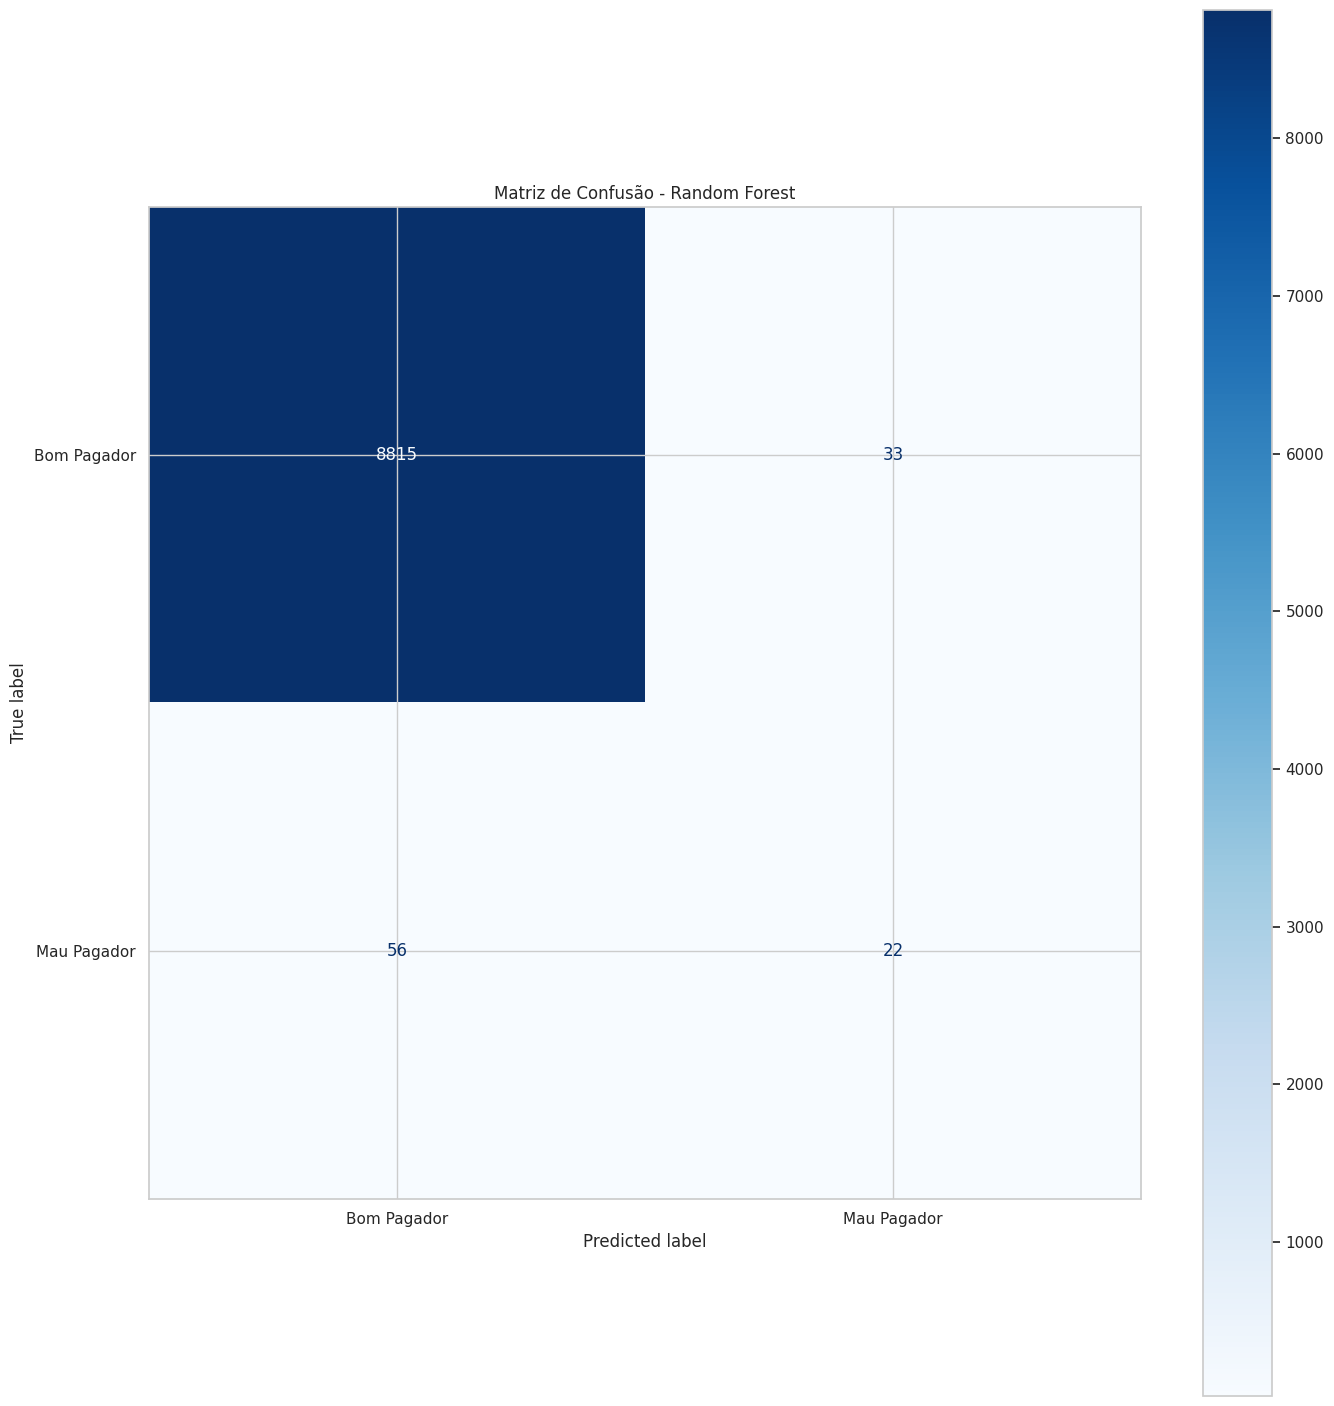

In [19]:
# Avaliando a probabilidade da classe positiva (Mau_Pagador = 1)
y_proba = modelo_rf.predict_proba(X_test)[:, 1]

# Fazendo a predição padrão com limiar 0.5
y_pred = (y_proba >= 0.5).astype(int)

# Exibe os resultados obtidos pelo modelo treinado
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Acurácia balanceada: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Precisão média: {average_precision_score(y_test, y_proba):.4f}\n")

# Exibe a matriz de confusão do modelo a fim de identificar seu desempenho
matriz = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Bom Pagador', 'Mau Pagador']
)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [20]:
# Ajustando os limiares de decisão do modelo
limiares = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

resultados_limiares = []

# Descobrindo as métricas do modelo para cada limiar de decisão testado
for limiar in limiares:
    y_pred_limiar = (y_proba >= limiar).astype(int)

    resultados_limiares.append({
        'Limiar': limiar,
        'Precisao': precision_score(y_test, y_pred_limiar, zero_division=0),
        'Recall': recall_score(y_test, y_pred_limiar, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_limiar, zero_division=0),
        'Acuracia_Balanceada': balanced_accuracy_score(y_test, y_pred_limiar)
    })

df_limiares = pd.DataFrame(resultados_limiares)
display(df_limiares)

,Limiar,Precisao,Recall,F1-score,Acuracia_Balanceada
0,0.05,0.014412,0.897436,0.028369,0.678205
1,0.10,0.017380,0.692308,0.033909,0.673629
2,0.15,0.023073,0.525641,0.044205,0.664719
3,0.20,0.040276,0.448718,0.073918,0.677230
4,0.25,0.069712,0.371795,0.117409,0.664028
5,0.30,0.135417,0.333333,0.192593,0.657286
6,0.40,0.296296,0.307692,0.301887,0.650625
7,0.50,0.400000,0.282051,0.330827,0.639161


# **Etapa 5: Regressão**

In [21]:
# Convertendo o status de pagamento para um score numérico
# C, X e 0 foram considerados comportamento regular, enquanto os status de 1 a 5 representam níveis progressivos de atraso
def converter_status_para_score(status):
    status = str(status)

    if status in ['C', 'X', '0']:
        return 0
    elif status == '1':
        return 1
    elif status == '2':
        return 2
    elif status == '3':
        return 3
    elif status == '4':
        return 4
    elif status == '5':
        return 5
    else:
        return 0

credit_reg = credit_df.copy()
credit_reg['Score_Comportamento'] = credit_reg['Status_Pagamento'].apply(
    converter_status_para_score
)

display(credit_reg)

,ID,Meses_no_Banco,Status_Pagamento,Status_Descricao,Score_Comportamento
0,5001711,0,X,Sem empréstimo,0
1,5001711,-1,0,Atraso leve (1-29 dias),0
2,5001711,-2,0,Atraso leve (1-29 dias),0
3,5001711,-3,0,Atraso leve (1-29 dias),0
4,5001712,0,C,Pago (Em dia),0
...,...,...,...,...,...
1048570,5150487,-25,C,Pago (Em dia),0
1048571,5150487,-26,C,Pago (Em dia),0
1048572,5150487,-27,C,Pago (Em dia),0
1048573,5150487,-28,C,Pago (Em dia),0


In [35]:
MESES_FUTUROS = 6  # Janela de avaliação futura -> Consideramos o número de meses ao lado como a janela que queremos prever dos clientes
GRAU_POLINOMIO = 2

previsoes = []

for cliente_id, dados_cliente in credit_reg.groupby('ID'):
    dados_cliente = dados_cliente.sort_values('Meses_no_Banco')

    X_cliente = dados_cliente[['Meses_no_Banco']]
    y_cliente = dados_cliente['Score_Comportamento']

    # Garante um histórico mínimo de 3 mêses para treinar os modelos
    if len(dados_cliente) < 3:
        continue

    # Modelo 1 -> Regressão Linear -> Permite identificar uma tendência geral de melhora, piora ou estabilidade no histórico de pagamentos
    modelo_linear = LinearRegression()
    modelo_linear.fit(X_cliente, y_cliente)

    # Modelo 2 -> Regressão Polinomial -> Permite capturar variações não lineares, representando melhor os casos em que o comportamento do cliente muda de outras formas ao longo do tempo
    modelo_polinomial = Pipeline([
        ('poly', PolynomialFeatures(degree=GRAU_POLINOMIO)),
        ('linear', LinearRegression())
    ])
    modelo_polinomial.fit(X_cliente, y_cliente)

    # Simulando os próximos meses
    meses_futuros = pd.DataFrame(np.arange(1, MESES_FUTUROS + 1).reshape(-1, 1), columns=['Meses_no_Banco'])
    pred_linear = modelo_linear.predict(meses_futuros)
    pred_polinomial = modelo_polinomial.predict(meses_futuros)

    # Limita o score das predições dos modelos entre 0 e 5, a fim de manter a coerência com os status originais
    pred_linear = np.clip(pred_linear, 0, 5)
    pred_polinomial = np.clip(pred_polinomial, 0, 5)

    for mes, score_lin, score_poly in zip(range(1, MESES_FUTUROS + 1), pred_linear, pred_polinomial):
        previsoes.append({
            'ID': cliente_id,
            'Mes_Futuro': mes,
            'Score_Previsto_Linear': score_lin,
            'Score_Previsto_Polinomial': score_poly
        })

df_previsoes_regressao = pd.DataFrame(previsoes)
display(df_previsoes_regressao)

,ID,Mes_Futuro,Score_Previsto_Linear,Score_Previsto_Polinomial
0,5001711,1,0.0,0.0
1,5001711,2,0.0,0.0
2,5001711,3,0.0,0.0
3,5001711,4,0.0,0.0
4,5001711,5,0.0,0.0
...,...,...,...,...
266983,5150487,2,0.0,0.0
266984,5150487,3,0.0,0.0
266985,5150487,4,0.0,0.0
266986,5150487,5,0.0,0.0


In [36]:
# Interpretando o comportamento previsto pelos modelos treinados
def interpretar_score(score):
    if score < 0.5:
        return 'Comportamento Regular'
    elif score < 1.5:
        return 'Tendência de Atraso Leve'
    elif score < 2.5:
        return 'Tendência de Atraso Moderado'
    else:
        return 'Tendência de Atraso Grave'

df_previsoes_regressao['Comportamento_Linear'] = (
    df_previsoes_regressao['Score_Previsto_Linear'].apply(interpretar_score)
)

df_previsoes_regressao['Comportamento_Polinomial'] = (
    df_previsoes_regressao['Score_Previsto_Polinomial'].apply(interpretar_score)
)

display(df_previsoes_regressao)

,ID,Mes_Futuro,Score_Previsto_Linear,Score_Previsto_Polinomial,Comportamento_Linear,Comportamento_Polinomial
0,5001711,1,0.0,0.0,Comportamento Regular,Comportamento Regular
1,5001711,2,0.0,0.0,Comportamento Regular,Comportamento Regular
2,5001711,3,0.0,0.0,Comportamento Regular,Comportamento Regular
3,5001711,4,0.0,0.0,Comportamento Regular,Comportamento Regular
4,5001711,5,0.0,0.0,Comportamento Regular,Comportamento Regular
...,...,...,...,...,...,...
266983,5150487,2,0.0,0.0,Comportamento Regular,Comportamento Regular
266984,5150487,3,0.0,0.0,Comportamento Regular,Comportamento Regular
266985,5150487,4,0.0,0.0,Comportamento Regular,Comportamento Regular
266986,5150487,5,0.0,0.0,Comportamento Regular,Comportamento Regular


,Mes_Futuro,Media_Linear,Media_Polinomial
0,1,0.033732,0.033836
1,2,0.035364,0.037342
2,3,0.036973,0.040536
3,4,0.038544,0.043644
4,5,0.040104,0.046440
5,6,0.041654,0.048960


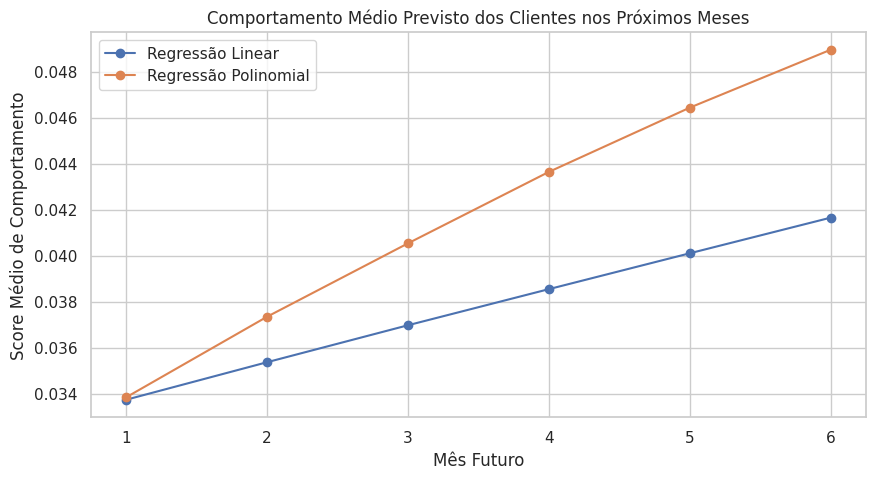

In [37]:
# Analisando o comportamento médio previsto dos clientes
comportamento_medio = df_previsoes_regressao.groupby('Mes_Futuro').agg(
    Media_Linear=('Score_Previsto_Linear', 'mean'),
    Media_Polinomial=('Score_Previsto_Polinomial', 'mean')
).reset_index()

# Exibindo a tabela de comportamento médio previsto dos clientes
display(comportamento_medio)

# Exibindo o gráfico de comportamento médio previsto dos clientes
plt.figure(figsize=(10, 5))
plt.plot(
    comportamento_medio['Mes_Futuro'],
    comportamento_medio['Media_Linear'],
    marker='o',
    label='Regressão Linear'
)
plt.plot(
    comportamento_medio['Mes_Futuro'],
    comportamento_medio['Media_Polinomial'],
    marker='o',
    label='Regressão Polinomial'
)
plt.title('Comportamento Médio Previsto dos Clientes nos Próximos Meses')
plt.xlabel('Mês Futuro')
plt.ylabel('Score Médio de Comportamento')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Encontrando os melhores e piores clientes a partir das previsões realizadas
clientes_pior_tendencia = df_previsoes_regressao.sort_values(
    by='Score_Previsto_Polinomial',
    ascending=False
)

display(clientes_pior_tendencia)

,ID,Mes_Futuro,Score_Previsto_Linear,Score_Previsto_Polinomial,Comportamento_Linear,Comportamento_Polinomial
65793,5025170,4,1.098901,5.0,Tendência de Atraso Leve,Tendência de Atraso Grave
65794,5025170,5,1.123077,5.0,Tendência de Atraso Leve,Tendência de Atraso Grave
65795,5025170,6,1.147253,5.0,Tendência de Atraso Leve,Tendência de Atraso Grave
56447,5023058,6,0.000000,5.0,Comportamento Regular,Tendência de Atraso Grave
56446,5023058,5,0.000000,5.0,Comportamento Regular,Tendência de Atraso Grave
...,...,...,...,...,...,...
91187,5044520,6,0.000000,0.0,Comportamento Regular,Comportamento Regular
91188,5044528,1,0.000000,0.0,Comportamento Regular,Comportamento Regular
91189,5044528,2,0.000000,0.0,Comportamento Regular,Comportamento Regular
91190,5044528,3,0.000000,0.0,Comportamento Regular,Comportamento Regular


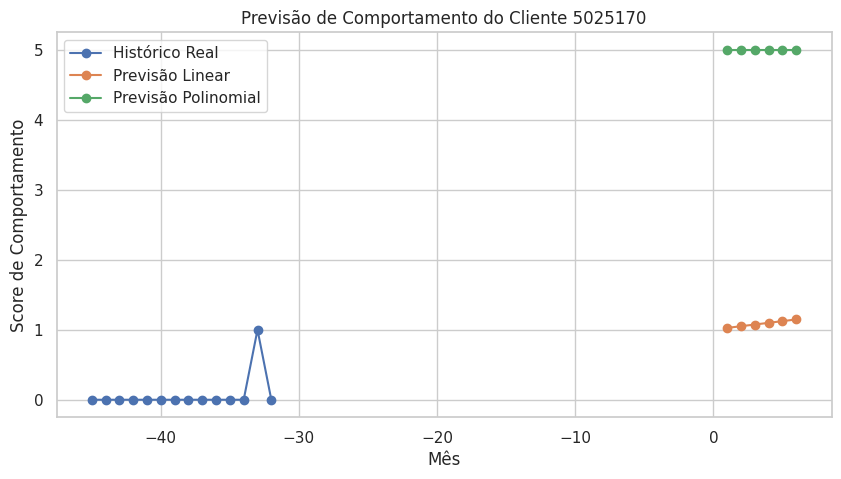

In [39]:
# Analisando o comportamento previsto de um cliente em específico
cliente_exemplo = df_previsoes_regressao['ID'].iloc[65795]

# Encontrando os dados previstos desse cliente
historico_cliente = credit_reg[
    credit_reg['ID'] == cliente_exemplo
].sort_values('Meses_no_Banco')

previsao_cliente = df_previsoes_regressao[
    df_previsoes_regressao['ID'] == cliente_exemplo
]

# Exibindo graficamente a previsão desse cliente
plt.figure(figsize=(10, 5))
plt.plot(
    historico_cliente['Meses_no_Banco'],
    historico_cliente['Score_Comportamento'],
    marker='o',
    label='Histórico Real'
)
plt.plot(
    previsao_cliente['Mes_Futuro'],
    previsao_cliente['Score_Previsto_Linear'],
    marker='o',
    label='Previsão Linear'
)
plt.plot(
    previsao_cliente['Mes_Futuro'],
    previsao_cliente['Score_Previsto_Polinomial'],
    marker='o',
    label='Previsão Polinomial'
)
plt.title(f'Previsão de Comportamento do Cliente {cliente_exemplo}')
plt.xlabel('Mês')
plt.ylabel('Score de Comportamento')
plt.legend()
plt.grid(True)
plt.show()

# **Etapa 6: Análise Não Supervisionada**

In [27]:
# Selecionando as variáveis que serão utilizadas no treino do modelo
cols_treino = [
    'Idade', 'Renda_Anual', 'Anos_Empregado', 'Qtd_Filhos', 'Tamanho_Familia',
    'Qtd_Meses_Historico', 'Qtd_Atrasos_Leves', 'Qtd_Atrasos_Graves',
    'Qtd_Meses_Pagos', 'Qtd_Meses_Sem_Emprestimo', 'Percentual_Atrasos_Graves'
]

# Para este modelo, utilizamos o df_puro criada na etapa 1, já que este ainda conta com os outliers do dataset
df_puro[cols_treino] = df_puro[cols_treino].fillna(0)
X_completo = df_puro[cols_treino].copy()

# Padronização dos dados
scaler_unsup = StandardScaler()
X_completo_scaled = scaler_unsup.fit_transform(X_completo)

In [28]:
# Detectando as anomalias no dataframe
# O parametro contamination dita o percentual de dados que devem ser considerados como anomalias
iso_forest = IsolationForest(n_estimators=200, contamination=0.0015, random_state=42)
df_puro['Flag_Anomalia'] = iso_forest.fit_predict(X_completo_scaled)

anomalias_df = df_puro[df_puro['Flag_Anomalia'] == -1]
print(f"{len(anomalias_df)} anomalias detectadas!")
display(anomalias_df)

45 anomalias detectadas!


,ID,Genero,Tem_Carro,Tem_Imovel,Qtd_Filhos,Renda_Anual,Tipo_Renda,Escolaridade,Estado_Civil,Tipo_Moradia,Idade,Anos_Empregado,Tem_Celular,Tem_Tel_Trabalho,Tem_Tel_Fixo,Tem_Email,Profissao,Tamanho_Familia,Mau_Pagador,Qtd_Meses_Historico,Qtd_Atrasos_Leves,Qtd_Atrasos_Graves,Qtd_Meses_Pagos,Qtd_Meses_Sem_Emprestimo,Percentual_Atrasos_Graves,Flag_Anomalia
1358,5010864,M,S,S,1,450000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,50.0,2.0,1,0,1,1,Core staff,3.0,0,39.0,11.0,6.0,22.0,0.0,0.153846,-1
3296,5023896,F,N,N,1,90000.0,Pensioner,Secondary / secondary special,Married,House / apartment,50.0,0.0,1,0,0,0,Nao Informado,3.0,0,43.0,40.0,3.0,0.0,0.0,0.069767,-1
3857,5025155,F,N,S,1,202500.0,Working,Higher education,Single / not married,House / apartment,28.0,0.0,1,0,1,0,Accountants,2.0,0,46.0,29.0,5.0,11.0,1.0,0.108696,-1
4981,5029165,F,N,S,3,292500.0,Working,Incomplete higher,Married,House / apartment,33.0,11.0,1,1,0,0,Nao Informado,5.0,0,46.0,41.0,0.0,0.0,5.0,0.000000,-1
8421,5045894,F,N,S,0,225000.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,64.0,0.0,1,0,0,0,Nao Informado,1.0,0,40.0,2.0,8.0,30.0,0.0,0.200000,-1
11067,5054524,F,N,N,2,180000.0,Working,Secondary / secondary special,Married,House / apartment,45.0,23.0,1,0,0,0,Nao Informado,4.0,0,45.0,9.0,1.0,0.0,35.0,0.022222,-1
11454,5058345,F,N,S,0,99000.0,Pensioner,Higher education,Separated,House / apartment,67.0,0.0,1,0,0,0,Nao Informado,1.0,0,43.0,4.0,12.0,6.0,21.0,0.279070,-1
11618,5061091,F,S,N,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,30.0,9.0,1,1,0,0,Sales staff,5.0,0,43.0,10.0,4.0,29.0,0.0,0.093023,-1
11707,5061207,M,S,S,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,49.0,5.0,1,0,0,0,Drivers,15.0,0,46.0,26.0,0.0,0.0,20.0,0.000000,-1
12042,5061636,F,N,S,0,225000.0,Pensioner,Secondary / secondary special,Married,Municipal apartment,59.0,0.0,1,0,1,0,Nao Informado,2.0,0,46.0,7.0,6.0,13.0,20.0,0.130435,-1


In [29]:
# Clusterizando o dataframe a fim de detectar padrões nos diferentes grupos de clientes
N_GRUPOS = 6
kmeans = KMeans(n_clusters=N_GRUPOS, random_state=42)
df_puro['Grupo_Cliente'] = kmeans.fit_predict(X_completo_scaled)

In [30]:
# Separando as colunas númericas das conceituais
cols_numericas = df_puro.select_dtypes(include=[np.number]).columns.drop(['ID', 'Flag_Anomalia', 'Grupo_Cliente'], errors='ignore')
cols_categoricas = df_puro.select_dtypes(exclude=[np.number]).columns

# Para as colunas númericas, tiramos a média de valores encontrados na clusterização para sua análise
resumo_num = df_puro.groupby('Grupo_Cliente')[cols_numericas].mean().round(2)

# Para as colunas conceituais, pegamos a moda do grupo
resumo_cat = df_puro.groupby('Grupo_Cliente')[cols_categoricas].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "N/A")

# Fundimos as duas tabelas para análise dos resultados
resumo_completo = pd.concat([resumo_num, resumo_cat], axis=1)
resumo_completo['Tamanho_do_Grupo'] = df_puro.groupby('Grupo_Cliente').size()

display(resumo_completo)

,Qtd_Filhos,Renda_Anual,Idade,Anos_Empregado,Tem_Celular,Tem_Tel_Trabalho,Tem_Tel_Fixo,Tem_Email,Tamanho_Familia,Mau_Pagador,Qtd_Meses_Historico,Qtd_Atrasos_Leves,Qtd_Atrasos_Graves,Qtd_Meses_Pagos,Qtd_Meses_Sem_Emprestimo,Percentual_Atrasos_Graves,Genero,Tem_Carro,Tem_Imovel,Tipo_Renda,Escolaridade,Estado_Civil,Tipo_Moradia,Profissao,Tamanho_do_Grupo
Grupo_Cliente,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.18,185546.63,46.00,6.83,1.0,0.23,0.30,0.09,1.95,0.00,33.44,12.05,0.08,20.01,1.30,0.00,F,N,S,Working,Secondary / secondary special,Married,House / apartment,Nao Informado,5179
1,0.41,181508.82,47.28,4.85,1.0,0.32,0.34,0.03,2.13,0.65,28.72,8.16,14.03,3.06,3.47,0.49,F,N,S,Working,Secondary / secondary special,Married,House / apartment,Nao Informado,68
2,2.43,190645.26,37.14,7.24,1.0,0.29,0.28,0.08,4.39,0.01,24.33,10.26,0.07,11.31,1.60,0.00,F,N,S,Working,Secondary / secondary special,Married,House / apartment,Nao Informado,1297
3,0.36,196204.04,44.28,6.89,1.0,0.25,0.33,0.09,2.16,0.00,30.04,2.46,0.05,1.22,26.31,0.00,F,N,S,Working,Secondary / secondary special,Married,House / apartment,Nao Informado,1612
4,1.26,195441.05,36.42,5.96,1.0,0.25,0.27,0.11,3.16,0.01,12.73,5.84,0.01,1.50,1.14,0.00,F,N,S,Working,Secondary / secondary special,Married,House / apartment,Laborers,6193
5,0.01,183056.63,46.28,5.53,1.0,0.21,0.30,0.09,1.71,0.01,12.60,5.96,0.01,1.22,0.98,0.00,F,N,S,Working,Secondary / secondary special,Married,House / apartment,Nao Informado,15402


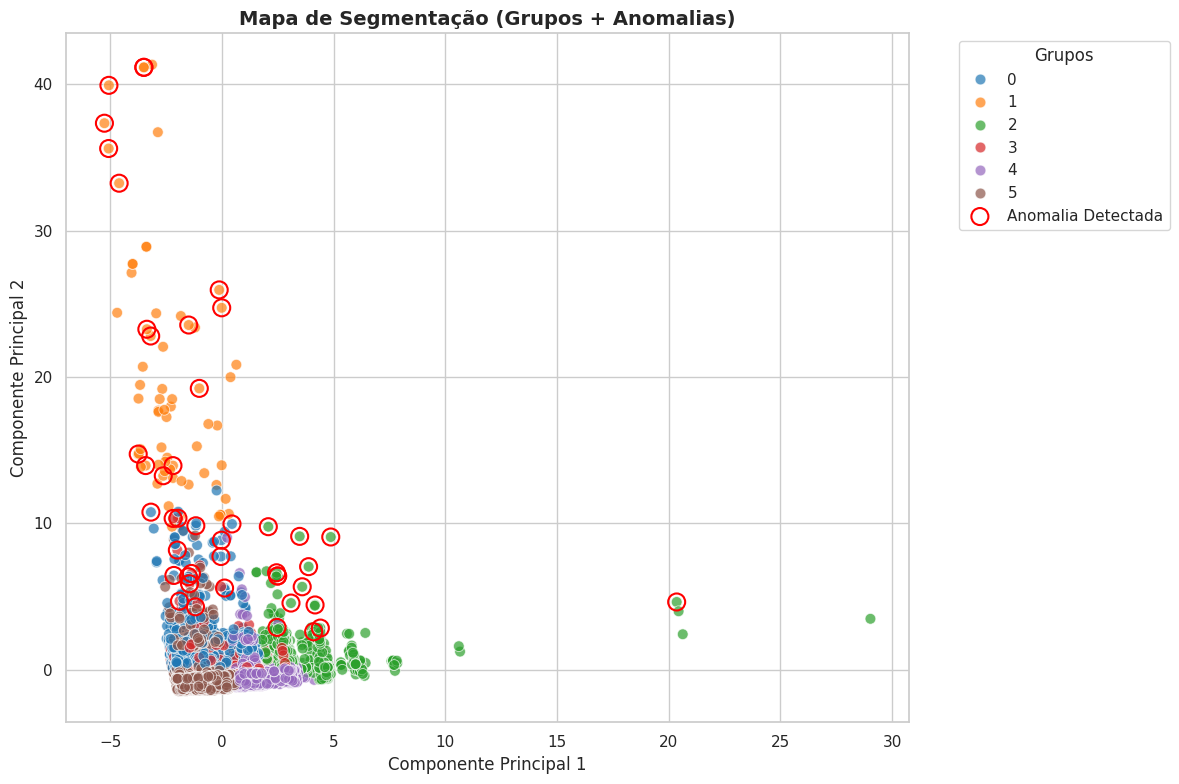

In [31]:
# Como o dataset conta com muitas colunas, utilizamos PCA para converte-las em apenas duas componentes
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(X_completo_scaled)
df_puro['PCA_1'] = componentes_pca[:, 0]
df_puro['PCA_2'] = componentes_pca[:, 1]

# Visualização gráfica das anomalias e dos grupos encontrados
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_puro, x='PCA_1', y='PCA_2',
    hue='Grupo_Cliente', palette='tab10',
    alpha=0.7, s=60
)
sns.scatterplot(
    data=df_puro[df_puro['Flag_Anomalia'] == -1], x='PCA_1', y='PCA_2',
    color='none', edgecolor='red', linewidth=1.5,
    s=150, label='Anomalia Detectada'
)
plt.title('Mapa de Segmentação (Grupos + Anomalias)', fontweight='bold', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Excluindo as colunas de PCA, já que não serão mais úteis nas próximas análises
df.drop(columns=['PCA_1', 'PCA_2'], inplace=True, errors='ignore')

# Conclusões

1. Desempenho dos Modelos:  
Lidar com a concessão de crédito exige contornar o severo desbalanceamento das classes, já que a grande maioria dos clientes paga em dia, mesmo assim, após o treinamento e a validação dos algoritmos, concluímos que os modelos apresentaram um desempenho sólido e consistente, comprovado pelas métricas de Recall, F1-Score e pela análise gráfica da Matriz de Confusão e dos limiares de decisão.

2. Pré-processamento:  
Como na grande maioria dos projetos de Inteligência Artificial, o pré-processamento provou ser um dos pilares fundamentais para o sucesso das predições. Foi a partir da aplicação de técnicas como Target Encoding para variáveis categóricas, RobustScaler e StandardScaler para padronização de escalas, aliadas à Winsorização para suavização de outliers extremos, que os modelos puderam encontrar os padrões dos dados utilizados.

3. Utilidade:  
Por fim, afirmamos com segurança que esta arquitetura não apenas seria útil em cenários reais, como reflete diretamente as técnicas já utilizadas pelas grandes instituições do sistema financeiro, tanto na identificação e reprodução de padrões quanto na previsão de comportamento de seus clientes.

# **Etapa Final: Salvamento dos Modelos**

In [40]:
# Definindo os nomes dos arquivos dos modelos
nome_classificacao = 'classificacao.pkl'
nome_regressao_linear = 'regressao_linear_ultimo_cliente.pkl'
nome_regressao_poli = 'regressao_polinomial_ultimo_cliente.pkl'
nome_nao_supervisionado = 'nao_supervisionado.pkl'

# Salva o modelo de classificação mantendo seu pipeline, fundamental para sua utilização, já que, quando utilizado, seus dados virão sem RobustScaler e sem TargetEncoder
joblib.dump(modelo_rf, nome_classificacao)

# Salva os modelos de regressão
# Observação: Como a regressão foi executada em um loop para cada cliente, os arquivos conterão apenas os pesos treinados para o último cliente
joblib.dump(modelo_linear, nome_regressao_linear)
joblib.dump(modelo_polinomial, nome_regressao_poli)

# Salva o modelo não supervisionado, mantendo seu dicionário com o Scaler, o Isolation Forest e o K-Means
modelos_unsup = {
    'scaler': scaler_unsup,
    'isolation_forest': iso_forest,
    'kmeans': kmeans
}
joblib.dump(modelos_unsup, nome_nao_supervisionado)

print("Modelos salvos com sucesso!")

Modelos salvos com sucesso!
